In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [3]:
# One week temperature data (Monday to Sunday)
# Typical temperatures for April/May

data = {
    'Day': ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    'Hannover': [12, 14, 16, 15, 13, 11, 10],
    'Hamburg': [11, 13, 15, 14, 12, 10, 9]
}

df = pd.DataFrame(data)
print("📊 One-Week Temperature Comparison: Hannover vs Hamburg")
print(df)

📊 One-Week Temperature Comparison: Hannover vs Hamburg
         Day  Hannover  Hamburg
0     Monday        12       11
1    Tuesday        14       13
2  Wednesday        16       15
3   Thursday        15       14
4     Friday        13       12
5   Saturday        11       10
6     Sunday        10        9


In [4]:
hannover_avg = df['Hannover'].mean()
hamburg_avg = df['Hamburg'].mean()

print(f"🌡️ Hannover average: {hannover_avg:.1f}°C")
print(f"🌡️ Hamburg average: {hamburg_avg:.1f}°C")
print()

if hannover_avg > hamburg_avg:
    print("✅ Answer: Hannover is overall warmer this week")
else:
    print("✅ Answer: Hamburg is overall warmer this week")

🌡️ Hannover average: 13.0°C
🌡️ Hamburg average: 12.0°C

✅ Answer: Hannover is overall warmer this week


In [5]:
df['Difference'] = abs(df['Hannover'] - df['Hamburg'])
max_diff = df.loc[df['Difference'].idxmax()]

print(f"🔴 Biggest temperature difference: {max_diff['Difference']}°C on {max_diff['Day']}")
print(f"   Hannover: {max_diff['Hannover']}°C | Hamburg: {max_diff['Hamburg']}°C")

🔴 Biggest temperature difference: 1°C on Monday
   Hannover: 12°C | Hamburg: 11°C


In [7]:
hannover_fluctuation = df['Hannover'].std()
hamburg_fluctuation = df['Hamburg'].std()

print(f"📈 Hannover temperature fluctuation: {hannover_fluctuation:.2f}")
print(f"📈 Hamburg temperature fluctuation: {hamburg_fluctuation:.2f}")
print()

if hannover_fluctuation > hamburg_fluctuation:
    print("✅ Answer: Hannover shows stronger temperature changes during the week")
else:
    print("✅ Answer: Hamburg shows stronger temperature changes during the week")

📈 Hannover temperature fluctuation: 2.16
📈 Hamburg temperature fluctuation: 2.16

✅ Answer: Hamburg shows stronger temperature changes during the week


In [13]:
# Save the data to a CSV file
csv_filename = 'temperature_data.csv'
df.to_csv(csv_filename, index=False)

print(f"✅ CSV file saved as: {csv_filename}")
print(f"📁 Location: {csv_filename}")
print("\n📄 File contents preview:")
print(df)

✅ CSV file saved as: temperature_data.csv
📁 Location: temperature_data.csv

📄 File contents preview:
         Day  Hannover  Hamburg  Difference
0     Monday        12       11           1
1    Tuesday        14       13           1
2  Wednesday        16       15           1
3   Thursday        15       14           1
4     Friday        13       12           1
5   Saturday        11       10           1
6     Sunday        10        9           1


In [14]:
# Verify by reading the CSV file back
df_loaded = pd.read_csv(csv_filename)

print("✅ CSV file loaded successfully!")
print("\n📖 Data from CSV file:")
print(df_loaded)
print(f"\n📊 Shape: {df_loaded.shape[0]} rows × {df_loaded.shape[1]} columns")

✅ CSV file loaded successfully!

📖 Data from CSV file:
         Day  Hannover  Hamburg  Difference
0     Monday        12       11           1
1    Tuesday        14       13           1
2  Wednesday        16       15           1
3   Thursday        15       14           1
4     Friday        13       12           1
5   Saturday        11       10           1
6     Sunday        10        9           1

📊 Shape: 7 rows × 4 columns


/tmp/ipykernel_4209/270273917.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(fluctuation_data, labels=['Hannover', 'Hamburg'], patch_artist=True,


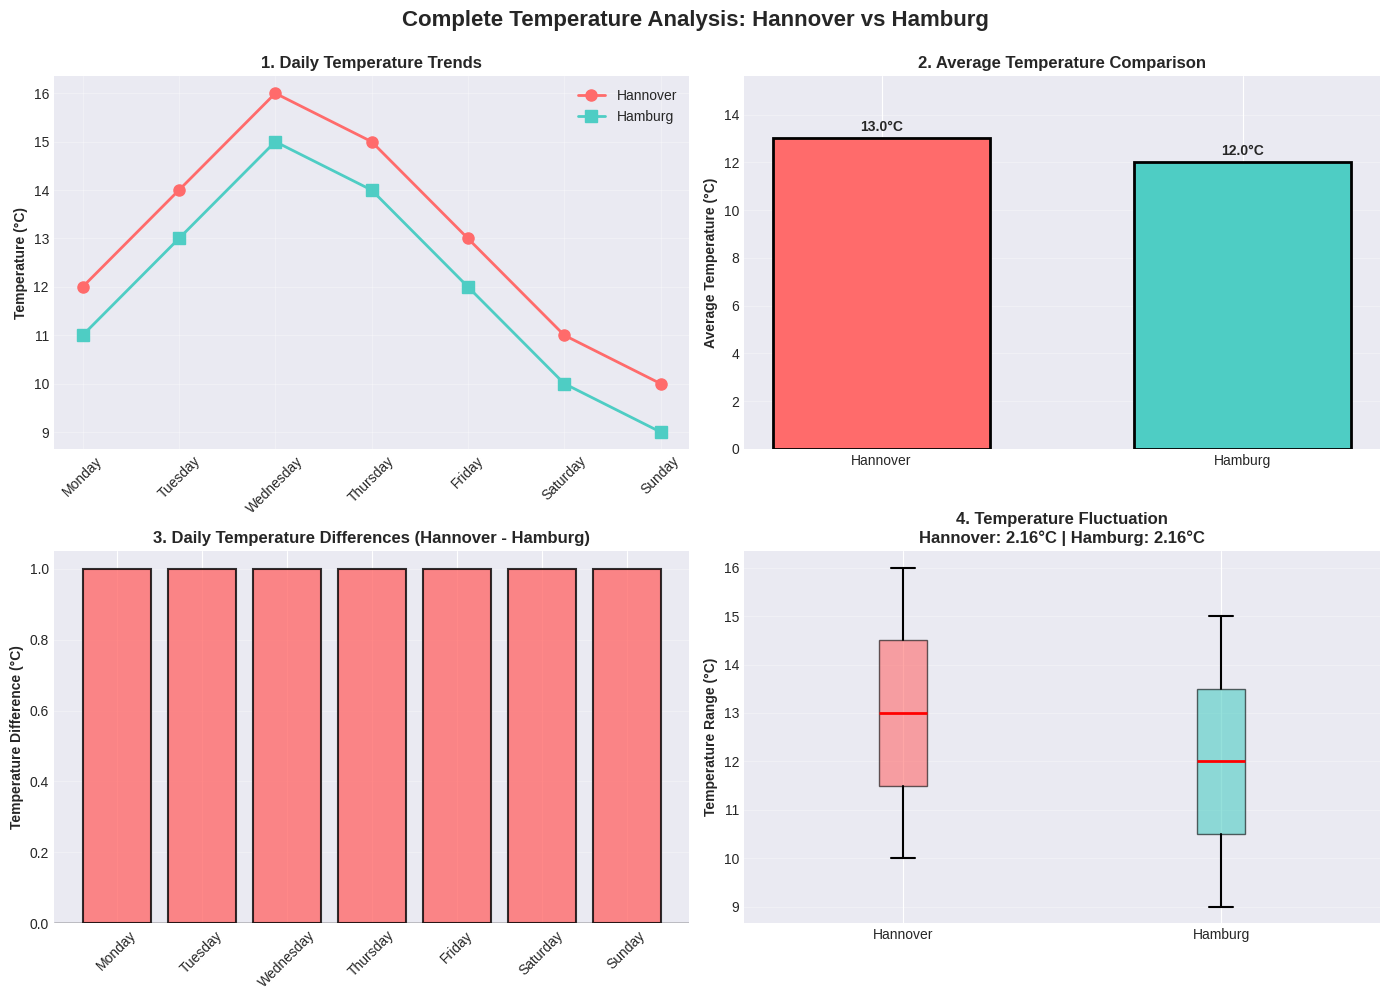

In [15]:
# Create a comprehensive visualization with all 4 analyses
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Complete Temperature Analysis: Hannover vs Hamburg', fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Daily Temperature Trends
ax1 = axes[0, 0]
ax1.plot(df['Day'], df['Hannover'], marker='o', linewidth=2, label='Hannover', color='#FF6B6B', markersize=8)
ax1.plot(df['Day'], df['Hamburg'], marker='s', linewidth=2, label='Hamburg', color='#4ECDC4', markersize=8)
ax1.set_ylabel('Temperature (°C)', fontweight='bold')
ax1.set_title('1. Daily Temperature Trends', fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Average Temperature Comparison
ax2 = axes[0, 1]
cities = ['Hannover', 'Hamburg']
averages = [hannover_avg, hamburg_avg]
bars = ax2.bar(cities, averages, color=['#FF6B6B', '#4ECDC4'], width=0.6, edgecolor='black', linewidth=2)
ax2.set_ylabel('Average Temperature (°C)', fontweight='bold')
ax2.set_title('2. Average Temperature Comparison', fontweight='bold')
ax2.set_ylim([0, max(averages) * 1.2])
for bar, val in zip(bars, averages):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{val:.1f}°C', ha='center', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Daily Temperature Differences
ax3 = axes[1, 0]
differences = df['Hannover'] - df['Hamburg']
colors = ['#FF6B6B' if x > 0 else '#4ECDC4' for x in differences]
bars = ax3.bar(df['Day'], differences, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax3.set_ylabel('Temperature Difference (°C)', fontweight='bold')
ax3.set_title('3. Daily Temperature Differences (Hannover - Hamburg)', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Temperature Fluctuation Comparison (Box Plot)
ax4 = axes[1, 1]
fluctuation_data = [df['Hannover'], df['Hamburg']]
bp = ax4.boxplot(fluctuation_data, labels=['Hannover', 'Hamburg'], patch_artist=True,
                  boxprops=dict(facecolor='lightblue', alpha=0.7),
                  medianprops=dict(color='red', linewidth=2),
                  whiskerprops=dict(linewidth=1.5),
                  capprops=dict(linewidth=1.5))

# Color the boxes
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax4.set_ylabel('Temperature Range (°C)', fontweight='bold')
ax4.set_title(f'4. Temperature Fluctuation\nHannover: {hannover_fluctuation:.2f}°C | Hamburg: {hamburg_fluctuation:.2f}°C', 
              fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()